<a href="https://colab.research.google.com/github/InahH-004/PCD_Collage/blob/main/2nd_Assignment/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Citra_derau2.jpg to Citra_derau2.jpg


In [57]:
print(uploaded)

{'Citra_derau2.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x08\x07\x06\t\x08\x07\x08\n\n\t\x0b\r\x16\x0f\r\x0c\x0c\r\x1b\x14\x15\x10\x16 \x1d"" \x1d\x1f\x1f$(4,$&1\'\x1f\x1f-=-157:::#+?D?8C49:7\x01\n\n\n\r\x0c\r\x1a\x0f\x0f\x1a7%\x1f%77777777777777777777777777777777777777777777777777\xff\xc0\x00\x11\x08\x01\xc9\x01\xb5\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1b\x00\x00\x02\x02\x03\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x03\x04\x02\x05\x00\x01\x06\x07\xff\xc4\x00G\x10\x00\x02\x02\x01\x03\x03\x03\x03\x02\x03\x04\x08\x05\x03\x01\t\x01\x02\x03\x11\x04\x12!1\x00\x13A\x05"Q\x142a#q\x06B\x81R\x91\xa1\xd1\x07\x15$3Tb\x93\xc1r\x82\xb1\xe1\xf0\x17C\xf14S\x92\xc2\xa2%c\x83\xb2\xf2\xff\xc4\x00\x14\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xc4\x00\x14\x11\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xda\x00\x0c\x03\x01\x00\x02\x11\x03\x11\x00?\x00\xef\x7f\x8

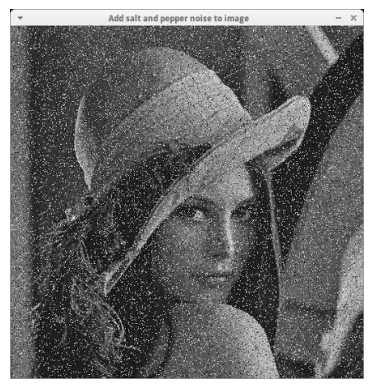

In [58]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

filename = list(uploaded.keys())[0]

img = mpimg.imread(filename)
plt.imshow(img)
plt.axis('off')
plt.show()

In [59]:
from PIL import Image
import numpy as np

img = Image.open(filename).convert('L')

pixel_matrix = np.array(img)

In [60]:
print(pixel_matrix)

[[  8   0   7 ...  11   0   5]
 [  0  29 104 ... 121  30   0]
 [  0 125 236 ... 228 108   0]
 ...
 [156  99  91 ...  42  21 142]
 [140  81  76 ...  23  33 136]
 [147 145 143 ... 139 142 146]]


In [61]:
def add_padding(img, kernel_size) :

  #untuk mendapatkan ukuran padding yg dibutuhkn
  pad = kernel_size // 2

  #mendapatkan ukuran photo
  tinggi = len(img)
  lebar = len(img[0])

  #img yg udah di padding
  padded_img = []

  #buat padding untuk tiap sisi (atas-bawah (2x tinggi) dan kiri-kakan(2x lebar))
  for i in range(tinggi + (2 * pad)) :
    baris_nol = [0] * (lebar + 2 * pad)
    padded_img.append(baris_nol)

  for i in range (tinggi) :
    for j in range (lebar) :
      padded_img[i + pad][j + pad] = img[i][j]

  return padded_img

In [62]:
gambar_padding = add_padding(pixel_matrix, 3)

In [63]:
def sliding_window(img_padded, kernel_size) :

  #tentukan ukuran padding
  pad = kernel_size // 2

  #ambil ukuran gambar orinya
  original_tinggi = len(img_padded) - 2 * pad
  original_lebar = len(img_padded[0]) - 2 * pad

  # inisiasi matriks untuk hasilnya nanti yang berikan value 0
  hasil = []
  for i in range (original_tinggi) :
    hasil.append([0] * original_lebar)

  # iterasi untuk ukuran img asli
  # The corresponding center pixel in `img_padded` will be at (r + pad, c + pad)
  for r in range (original_tinggi) :
    for c in range(original_lebar) :

      neighbor = []
      # cari tetangga pada gambar yg telah dipadding

      #Algoritma sliding window pada image asli
      for k_offset in range (-pad, pad + 1) :
        for l_offset in range (-pad, pad + 1) :

          # (r + pad) = indeks baris pada pusat karnel saat ini di img yang telah di padding
          # (c + pad) = vesi colomn nya

          neighbor_val = img_padded[(r + pad) + k_offset][(c + pad) + l_offset]
          neighbor.append(neighbor_val)

      neighbor.sort()
      indeks_median = len(neighbor)//2
      nilai_median = neighbor[indeks_median]
      hasil[r][c] = nilai_median

  return hasil

In [64]:
hasil = sliding_window(gambar_padding, 3)


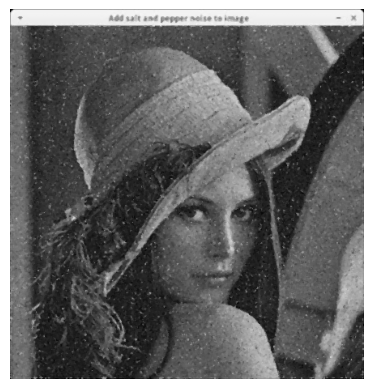

In [65]:
import numpy as np
import matplotlib.pyplot as plt

hasil = sliding_window(gambar_padding, 3)
hasil_array = np.array(hasil)

plt.figure()
plt.imshow(hasil_array, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()